# TUTORIAL SEABORN

### SEABORN vs MATPLOTLIB

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 


In [ ]:
# Set style ke 'classic' — tampilan default matplotlib jadul.
plt.style.use('classic')

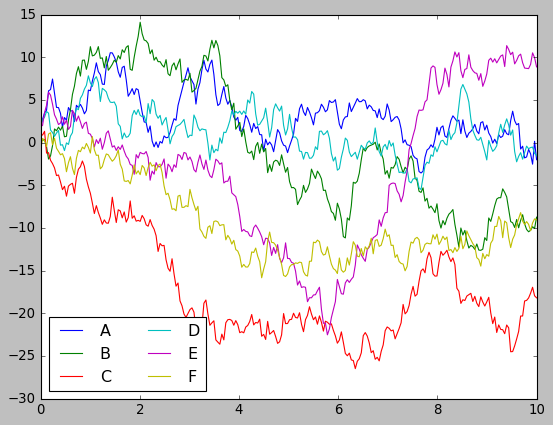

In [7]:
# **Random state seed** biar hasil random konsisten tiap run — buat reproducibility.
rng = np.random.RandomState(0)

# Bikin 250 titik dari 0 sampai 10 dengan jarak rata.
x = np.linspace(0,10,250)

# Bikin **6 random walk** — 6 garis acak yg diakumulasi.
y = np.cumsum(rng.randn(250, 6), 0)

plt.plot(x,y)
plt.legend('ABCDEF', ncol=2, loc='best')


# IMPORT SEABORN

In [5]:
import seaborn as sns

In [8]:
# `sns.set()` apply **theme default seaborn** — auto bikin grafik lebih estetik.
sns.set()

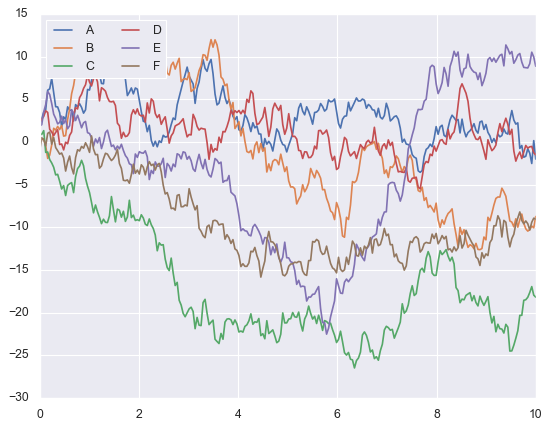

In [9]:
plt.plot(x,y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

In [24]:
# Berikan daftar nama kolom yang benar sesuai standar dataset Iris
nama_kolom = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# Load lagi datanya, tapi kasih tahu Pandas kalau file ini gak punya header bawaan
iris = pd.read_csv('DATASET/iris.data', header=None, names=nama_kolom)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [25]:
# Filter data: pisahin yg species 'setosa' & 'virginica' aja.
setosa=iris.loc[iris.species== "setosa"]
virginica = iris.loc[iris.species == "virginica"]



# Plot Histogram dan Kepadatan 

### histogram dan KDE bisa digabung. biar leih modern 

<Axes: xlabel='sepal_length', ylabel='Count'>

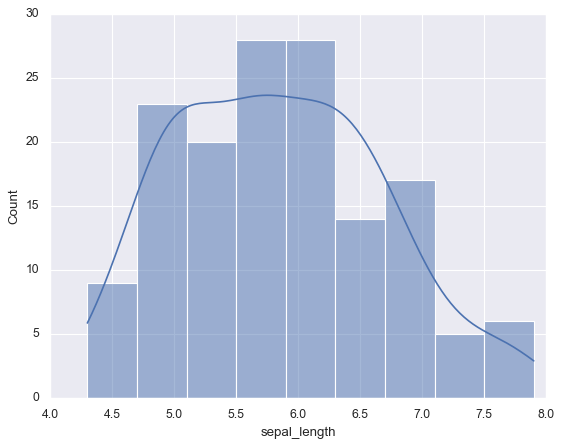

In [26]:
sns.histplot(iris.sepal_length, kde=True)

### Overlay 2 histogram: sepal_length (merah) vs sepal_width (biru) — bandingin distribusi.

<Axes: xlabel='sepal_length', ylabel='Count'>

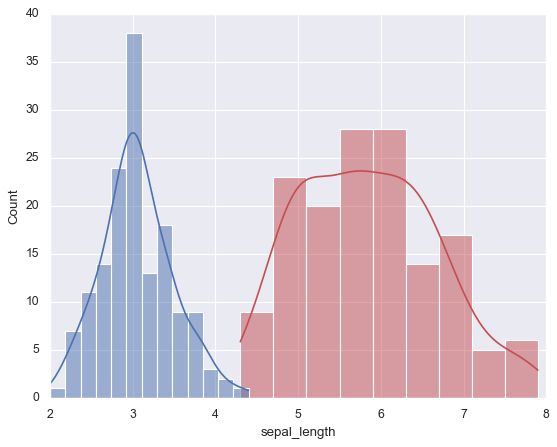

In [30]:
sns.histplot(iris.sepal_length, kde=True, color='r')
sns.histplot(iris.sepal_width, kde= True, color='b')

# GRAFIK 2 DIMENSI

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

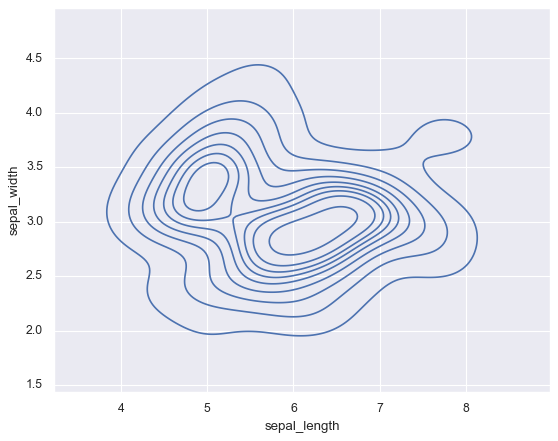

In [31]:
# 2D KDE - kontur density antar 2 variable 
sns.kdeplot(data = iris, x='sepal_length', y='sepal_width')

C:\Users\Rasky\AppData\Local\Temp\ipykernel_1992\3139528940.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data = iris, x='sepal_length', y='sepal_width', shade = True)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

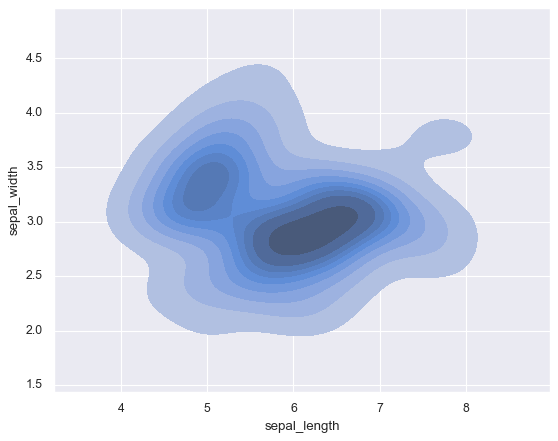

In [32]:
# sama tapi shade = True - kontur lebih solid berisi warna
sns.kdeplot(data = iris, x='sepal_length', y='sepal_width', shade = True)

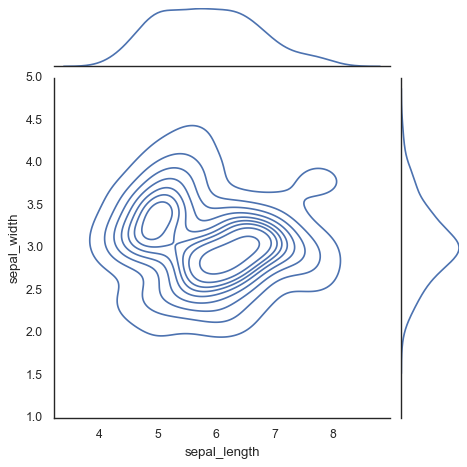

In [ ]:
# **Joint plot** = scatter di tengah + histogram di pinggir. `kind='kde'` pake density contour.

# 1. Bikin latar belakang grafik jadi putih bersih tanpa garis-garis kotak (grid)
with sns.axes_style('white'):
    
    # 2. Gambar grafik gabungan (Joint Plot)
    sns.jointplot(
        data=iris,            # Sumber datanya dari DataFrame 'iris'
        x="sepal_length",     # Kolom buat Sumbu X (lebar ke samping)
        y="sepal_width",      # Kolom buat Sumbu Y (tinggi ke atas)
        kind='kde'            # JENIS GRAFIK: Ubah titik data jadi garis melengkung (kontur gunung)
    )

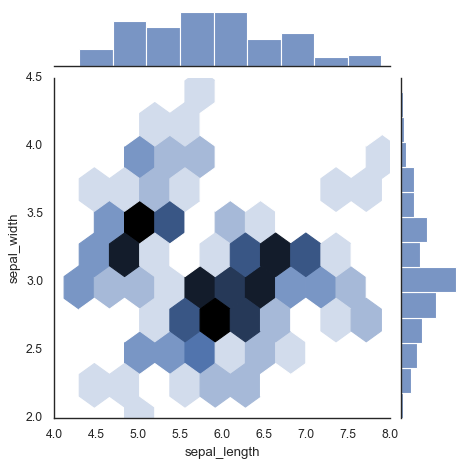

In [37]:
# Joint plot tapi `kind='hex'` — pake heksagonal bin (cocok buat data padat).
with sns.axes_style('white'):
    sns.jointplot(
        data = iris, 
        x = 'sepal_length',
        y = 'sepal_width',
        kind = 'hex'
    )

### **Pairplot** — plot semua kombinasi pasangan kolom. `hue='species'` warnain berdasarkan species.

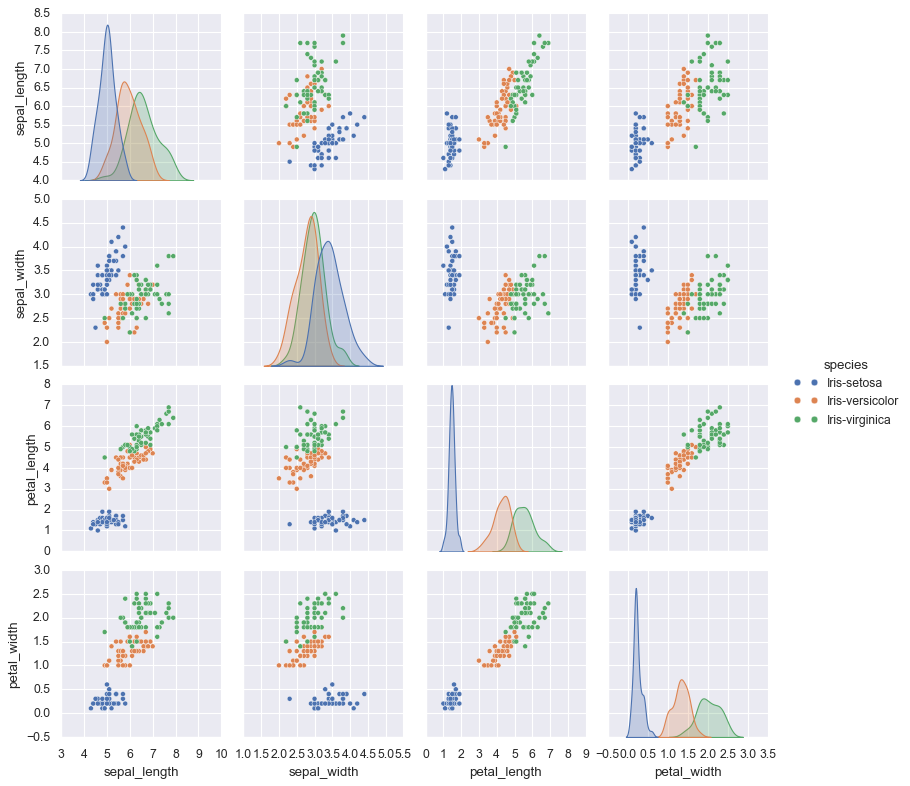

In [38]:
sns.pairplot(iris, hue='species')